# Library Import 

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

np.random.seed(42)

# Dataset 

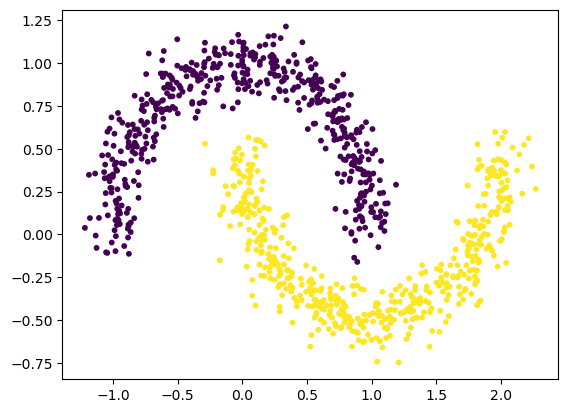

In [9]:
X, y = make_moons(n_samples=1000, 
                  random_state=42, 
                  noise=0.1)

plt.scatter(X[:, 0], X[:, 1], s=10, c=y)
plt.show()

# Data Normalize

In [10]:
X -= X.min()
X /= X.max()

# Shape

In [11]:
X = X.T
y = y.reshape(1, -1)

print(X.shape) 
print(y.shape)  

(2, 1000)
(1, 1000)


# Network Define

In [12]:
inputLayer_neurons  = X.shape[0]  
hiddenLayer_neurons = 10          
outputLayer_neurons = 1

lr     = 0.1
epochs = 10000                   

# Training

In [13]:
weights_input_hidden  = np.random.uniform(
                        size=(inputLayer_neurons,
                              hiddenLayer_neurons))
weights_hidden_output = np.random.uniform(
                        size=(hiddenLayer_neurons,
                              outputLayer_neurons))

losses = []

for epoch in range(epochs):
    # Forward Propagation
    hiddenLayer_linearTransform = np.dot(
                                  weights_input_hidden.T, X)
    hiddenLayer_activations     = sigmoid(
                                  hiddenLayer_linearTransform)
    outputLayer_linearTransform = np.dot(
                                  weights_hidden_output.T,
                                  hiddenLayer_activations)
    output                      = sigmoid(
                                  outputLayer_linearTransform)

    # Backward Propagation
    error        = np.square(y - output) / 2
    epoch_loss   = np.average(error)
    losses.append(epoch_loss)

    if epoch % 1000 == 0:
        print(f"Epoch {epoch} → Loss: {epoch_loss:.5f}")

Epoch 0 → Loss: 0.20915
Epoch 1000 → Loss: 0.20915
Epoch 2000 → Loss: 0.20915
Epoch 3000 → Loss: 0.20915
Epoch 4000 → Loss: 0.20915
Epoch 5000 → Loss: 0.20915
Epoch 6000 → Loss: 0.20915
Epoch 7000 → Loss: 0.20915
Epoch 8000 → Loss: 0.20915
Epoch 9000 → Loss: 0.20915


# loss  Plot

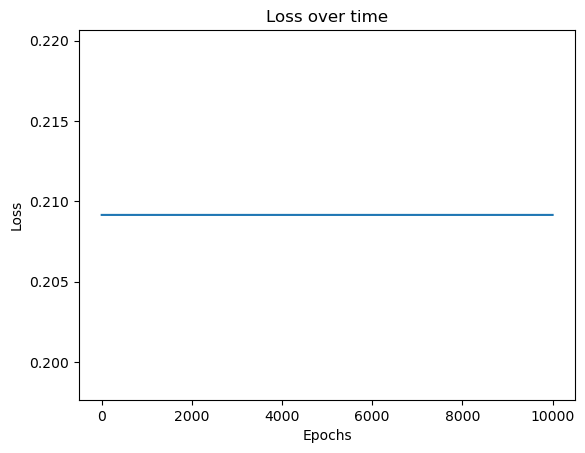

In [14]:
plt.plot(np.arange(1, epochs+1), np.array(losses))
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss over time")
plt.show()

 # Decision Boundary

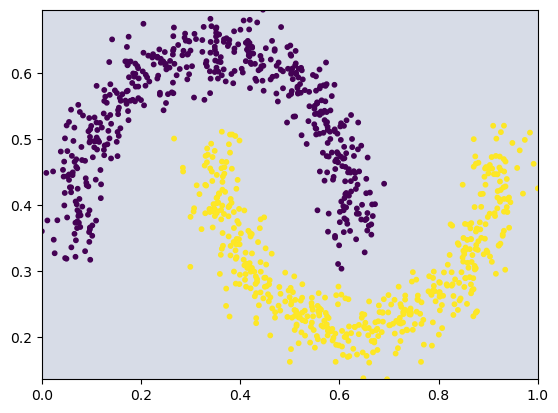

In [15]:
steps  = 1000
x_span = np.linspace(X[0,:].min(), X[0,:].max(), steps)
y_span = np.linspace(X[1,:].min(), X[1,:].max(), steps)
xx, yy = np.meshgrid(x_span, y_span)

# Forward pass
hiddenLayer_linearTransform = np.dot(
                              weights_input_hidden.T,
                              np.c_[xx.ravel(),
                              yy.ravel()].T)
hiddenLayer_activations     = sigmoid(hiddenLayer_linearTransform)
outputLayer_linearTransform = np.dot(
                              weights_hidden_output.T,
                              hiddenLayer_activations)
output_span                 = sigmoid(outputLayer_linearTransform)

labels = (output_span > 0.5).astype(int)

# Plot
z      = labels.reshape(xx.shape)
fig, ax = plt.subplots()
ax.contourf(xx, yy, z, alpha=0.2)
ax.scatter(X[0,:], X[1,:], s=10, c=y.squeeze())
plt.show()

Epoch 0 → Loss: 0.20915
Epoch 1000 → Loss: 0.02420
Epoch 2000 → Loss: 0.01231
Epoch 3000 → Loss: 0.00744
Epoch 4000 → Loss: 0.00721
Epoch 5000 → Loss: 0.00680
Epoch 6000 → Loss: 0.00661
Epoch 7000 → Loss: 0.00632
Epoch 8000 → Loss: 0.00618
Epoch 9000 → Loss: 0.00579


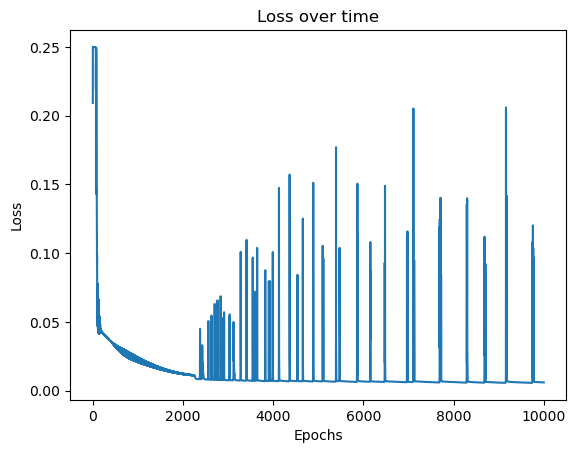

In [16]:


losses = []

for epoch in range(epochs):
    # Forward Propagation
    hiddenLayer_linearTransform = np.dot(
                                  weights_input_hidden.T, X)
    hiddenLayer_activations     = sigmoid(
                                  hiddenLayer_linearTransform)
    outputLayer_linearTransform = np.dot(
                                  weights_hidden_output.T,
                                  hiddenLayer_activations)
    output                      = sigmoid(
                                  outputLayer_linearTransform)

    # Backward Propagation
    error      = np.square(y - output) / 2
    epoch_loss = np.average(error)
    losses.append(epoch_loss)

    error_wrt_output = -(y - output)
    output_wrt_Z2    = np.multiply(output, (1-output))
    
    error_wrt_who    = np.dot(
                       hiddenLayer_activations,
                       (error_wrt_output * output_wrt_Z2).T)
    
    Z2_wrt_hidden    = weights_hidden_output
    hidden_wrt_Z1    = np.multiply(
                       hiddenLayer_activations,
                       (1-hiddenLayer_activations))
    
    error_wrt_wih    = np.dot(
                       X,
                       (hidden_wrt_Z1 * np.dot(
                        Z2_wrt_hidden,
                        (output_wrt_Z2 * error_wrt_output))).T)

    weights_hidden_output -= lr * error_wrt_who
    weights_input_hidden  -= lr * error_wrt_wih

    if epoch % 1000 == 0:
        print(f"Epoch {epoch} → Loss: {epoch_loss:.5f}")

# Loss Plot
plt.plot(np.arange(1, epochs+1), np.array(losses))
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss over time")
plt.show()

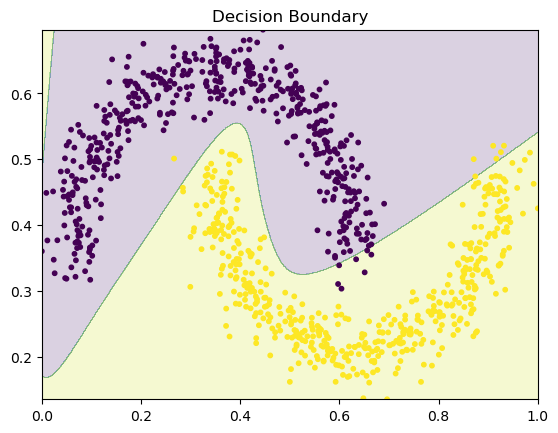

In [17]:
# Decision Boundary
steps  = 1000
x_span = np.linspace(X[0,:].min(), X[0,:].max(), steps)
y_span = np.linspace(X[1,:].min(), X[1,:].max(), steps)
xx, yy = np.meshgrid(x_span, y_span)

# Forward pass
hiddenLayer_linearTransform = np.dot(
                              weights_input_hidden.T,
                              np.c_[xx.ravel(),
                              yy.ravel()].T)
hiddenLayer_activations     = sigmoid(hiddenLayer_linearTransform)
outputLayer_linearTransform = np.dot(
                              weights_hidden_output.T,
                              hiddenLayer_activations)
output_span                 = sigmoid(outputLayer_linearTransform)

labels = (output_span > 0.5).astype(int)

# Plot
z       = labels.reshape(xx.shape)
fig, ax = plt.subplots()
ax.contourf(xx, yy, z, alpha=0.2)
ax.scatter(X[0,:], X[1,:], s=10, c=y.squeeze())
plt.title("Decision Boundary")
plt.show()